#  Bank Customer Churn Prediction
### Binary Classification using Machine Learning

---

##  Table of Contents
1. [Project Overview](#1)
   - 1.1 [Environment Setup](#1.1)
   - 1.2 [Load Libraries](#1.2)
   - 1.3 [Loading the Data](#1.3)
   - 1.4 [Variable Description](#1.4)
2. [Data Exploration](#2)
   - 2.1 [General Information](#2.1)
   - 2.2 [Missing Values](#2.2)
3. [Data Cleaning](#3)
   - 3.1 [Column Names](#3.1)
   - 3.2 [Remove Duplicates](#3.2)
   - 3.3 [Drop Unnecessary Columns](#3.3)
   - 3.4 [Standardize Text & Encode Binary Columns](#3.4)
   - 3.5 [Fix Data Types](#3.5)
   - 3.6 [Remove Impossible Values](#3.6)
   - 3.7 [Encode Categorical Features](#3.7)
   - 3.8 [Feature Engineering](#3.8)
   - 3.9 [Outliers Detection](#3.9)
   -  [Final Data Check](#3.9)
4. [Exploratory Data Analysis (EDA)](#4)
   - 4.1 [Target Distribution](#4.1)
   - 4.2 [Hypothesis 1 — Age](#4.2)
   - 4.3 [Hypothesis 2 — Balance](#4.3)
   - 4.4 [Hypothesis 3 — Gender](#4.4)
   - 4.5 [Geography & Products](#4.5)
   - 4.6 [Activity & Credit Card](#4.6)
   - 4.7 [Correlation Heatmap](#4.7)
5. [Modeling](#5)
   - 5.1 [Train-Test Split & Scaling](#5.1)
   - 5.2 [Handle Class Imbalance (SMOTE)](#5.2)
   - 5.3 [Baseline Model](#5.3)
   - 5.4 [KNN](#5.4)
   - 5.5 [Logistic Regression](#5.5)
   - 5.6 [Random Forest](#5.6)
6. [Model Evaluation & Comparison](#6)
   - 6.1 [Metrics Comparison Table](#6.1)
   - 6.2 [ROC Curves](#6.2)
   - 6.3 [Overfitting Check](#6.3)
   - 6.4 [Cross-Validation](#6.4)
   - 6.5 [Feature Importance](#6.5)
7. [Conclusion](#7)


# 1. Project Overview <a id='1'></a>

## 1.1 Environment Setup <a id='1.1'></a>

In [ ]:
import sys
print("Python version:", sys.version)
print("Environment location:", sys.executable)

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Environment location: /usr/bin/python3


## 1.2 Load Libraries <a id='1.2'></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             roc_curve, auc)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# SMOTE for class imbalance
from imblearn.over_sampling import SMOTE

# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

## 1.3 Loading the Data <a id='1.3'></a>

In [ ]:
# ── Load dataset ──────────────────────────────────────────────
# If using Google Colab, uncomment the two lines below:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("bank_churn_data.csv")

print(f"Shape: {df.shape}")
print(df.columns.tolist())

Saving bank_churn_data.csv to bank_churn_data.csv
Shape: (11000, 13)
['customerid ', 'surname ', 'creditscore ', 'geography ', 'gender ', 'age ', 'tenure ', 'balance ', 'numofproducts ', 'hascrcard ', 'isactivemember ', 'estimatedsalary ', 'exited ']


## 1.4 Variable Description <a id='1.4'></a>

| Variable | Type | Description |
|---|---|---|
| `CustomerId` | Identifier | Unique customer ID — **dropped** |
| `Surname` | Identifier | Customer's last name — **dropped** |
| `CreditScore` | Numeric | Credit worthiness score |
| `Geography` | Categorical | Country of residence (France / Germany / Spain) |
| `Gender` | Categorical | Customer gender |
| `Age` | Numeric | Customer age in years |
| `Tenure` | Numeric | Years as bank customer |
| `Balance` | Numeric | Account balance |
| `NumOfProducts` | Numeric | Number of bank products used |
| `HasCrCard` | Binary | Owns a credit card (1 = Yes) |
| `IsActiveMember` | Binary | Active bank user (1 = Yes) |
| `EstimatedSalary` | Numeric | Estimated annual income |
| `Exited` | **Target** | Customer churned (1 = Yes, 0 = No) |

### Prior Work
Customer churn prediction in the banking sector has been extensively studied as a binary classification problem. Ensemble methods such as Random Forests and Gradient Boosting consistently outperform simpler classifiers on tabular banking data. The benchmark Kaggle bank churn dataset has been tackled using approaches ranging from decision trees to deep neural networks, with ROC-AUC typically reported as the primary evaluation metric.


# 2. Data Exploration <a id='2'></a>

## 2.1 General Information <a id='2.1'></a>

In [ ]:
df.head()

,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,15634602,HARGRAVE,619,france,F,42,2,0.00,1,1,1,101348.88,1
1,15647311,HILL,608,SPAIN,f,41,1,83807.86,1,0,1,112542.58,0
2,15619304,onio,502,france,f,42,8,159660.80,3,1,0,113931.57,1
3,15701354,BONI,699,france,F,39,1,0.00,2,0,0,93826.63,0
4,15737888,mitchell,850,spain,F,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        11000 non-null  int64  
 1   surname           11000 non-null  object 
 2   creditscore       11000 non-null  int64  
 3   geography         11000 non-null  object 
 4   gender            11000 non-null  object 
 5   age               11000 non-null  int64  
 6   tenure            11000 non-null  int64  
 7   balance           11000 non-null  float64
 8   numofproducts     11000 non-null  int64  
 9   hascrcard         11000 non-null  int64  
 10  isactivemember    11000 non-null  int64  
 11  estimatedsalary   11000 non-null  float64
 12  exited            11000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe().round(2)

,customerid,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
count,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.00,11000.0
mean,15690901.89,649.97,38.92,5.02,76866.80,1.53,0.71,0.51,100279.21,0.2
std,71950.59,96.87,10.46,2.90,62351.84,0.58,0.46,0.50,57482.84,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628551.00,583.00,32.00,3.00,0.00,1.00,0.00,0.00,51271.41,0.0
50%,15690671.50,651.00,37.00,5.00,97600.36,1.00,1.00,1.00,100438.02,0.0
75%,15753007.75,717.00,44.00,8.00,127785.17,2.00,1.00,1.00,149472.02,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [ ]:
print("Rows:      ", df.shape[0])
print("Columns:   ", df.shape[1])
print("Duplicates:", df.duplicated().sum())

Rows:       11000
Columns:    13
Duplicates: 1000


### Output Analysis
- **Rows:** 11,000 &nbsp;|&nbsp; **Columns:** 13 &nbsp;|&nbsp; **Duplicates:** 1,000
- `CustomerId` and `Surname` are identifiers with no predictive value — will be dropped.
- The dataset appears to have no missing values (confirmed in 2.2 below), but column names and text fields need standardisation.


## 2.2 Missing Values <a id='2.2'></a>

In [ ]:
missing = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})

,Missing Count,Missing %
customerid,0,0.0
surname,0,0.0
creditscore,0,0.0
geography,0,0.0
gender,0,0.0
age,0,0.0
tenure,0,0.0
balance,0,0.0
numofproducts,0,0.0
hascrcard,0,0.0


### Output Analysis
No missing values are present in this dataset. However, we still call `dropna` on the target column as a safety measure after cleaning, in case type coercion introduces NaNs unexpectedly.


# 3. Data Cleaning <a id='3'></a>

## 3.1 Standardize Column Names <a id='3.1'></a>

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)
print(df.columns.tolist())

['customerid', 'surname', 'creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited']


## 3.2 Remove Duplicates <a id='3.2'></a>

In [ ]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after: ", df.duplicated().sum())
print("Rows remaining:   ", df.shape[0])

Duplicates before: 1000
Duplicates after:  0
Rows remaining:    10000


## 3.3 Drop Unnecessary Columns <a id='3.3'></a>

In [ ]:
df = df.drop(['customerid', 'surname'], axis=1)
print("Columns after drop:", df.columns.tolist())

Columns after drop: ['creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited']


## 3.4 Standardize Text & Encode Binary Columns <a id='3.4'></a>

In [ ]:
# Lowercase & strip all object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# Map yes/no variants → 1/0
yes_no_map = {"yes": 1, "no": 0, "1": 1, "0": 0, "y": 1, "n": 0}
for col in df.columns:
    unique_vals = set(df[col].dropna().astype(str).unique())
    if unique_vals.issubset(set(yes_no_map.keys())):
        df[col] = df[col].astype(str).map(yes_no_map)

# Standardize gender labels
if "gender" in df.columns:
    df["gender"] = df["gender"].replace({
        "male": "male", "m": "male",
        "female": "female", "f": "female"
    })

print(df.head())

   creditscore geography  gender  age  tenure    balance  numofproducts  \
0          619    france  female   42       2       0.00              1   
1          608     spain  female   41       1   83807.86              1   
2          502    france  female   42       8  159660.80              3   
3          699    france  female   39       1       0.00              2   
4          850     spain  female   43       2  125510.82              1   

   hascrcard  isactivemember  estimatedsalary  exited  
0          1               1        101348.88       1  
1          0               1        112542.58       0  
2          1               0        113931.57       1  
3          0               0         93826.63       0  
4          1               1         79084.10       0  


## 3.5 Fix Data Types <a id='3.5'></a>

In [ ]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        pass  # keep as categorical

print(df.dtypes)

creditscore          int64
geography           object
gender              object
age                  int64
tenure               int64
balance            float64
numofproducts        int64
hascrcard            int64
isactivemember       int64
estimatedsalary    float64
exited               int64
dtype: object


## 3.6 Remove Impossible Values <a id='3.6'></a>

In [ ]:
# Balance cannot be negative
rows_before = df.shape[0]
df = df[df["balance"] >= 0]
print(f"Removed {rows_before - df.shape[0]} rows with negative balance")

# Safety drop on target
df = df.dropna(subset=['exited'])
print("Final rows:", df.shape[0])

Removed 0 rows with negative balance
Final rows: 10000


## 3.7 Encode Categorical Features <a id='3.7'></a>

In [ ]:
df = pd.get_dummies(df, columns=["geography", "gender"], drop_first=True)
print("Columns after encoding:", df.columns.tolist())

Columns after encoding: ['creditscore', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited', 'geography_germany', 'geography_spain', 'gender_male']


## 3.8 Feature Engineering <a id='3.8'></a>

In [ ]:
# Balance-to-Salary ratio — captures relative wealth
df['balance_salary_ratio'] = df['balance'] / (df['estimatedsalary'] + 1)

# Zero-balance flag — customers with empty accounts may behave differently
df['zero_balance'] = (df['balance'] == 0).astype(int)

print("New features added: balance_salary_ratio, zero_balance")
df[['balance_salary_ratio', 'zero_balance']].describe()

New features added: balance_salary_ratio, zero_balance


,balance_salary_ratio,zero_balance
count,10000.000000,10000.000000
mean,3.790150,0.361700
std,100.055758,0.480517
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.746998,0.000000
75%,1.514002,1.000000
max,9770.883148,1.000000


## 3.9 Outliers Detection <a id='3.8'></a>

In [ ]:
print("\n========== OUTLIERS CHECK ==========")

print("\nAGE:")
print("Min:", df['age'].min())
print("Max:", df['age'].max())
print("Mean:", df['age'].mean())

print("\nBALANCE:")
print("Min:", df['balance'].min())
print("Max:", df['balance'].max())
print("Mean:", df['balance'].mean())



========== OUTLIERS CHECK ==========

AGE:
Min: 18
Max: 92
Mean: 38.9218

BALANCE:
Min: 0.0
Max: 250898.09
Mean: 76485.889288


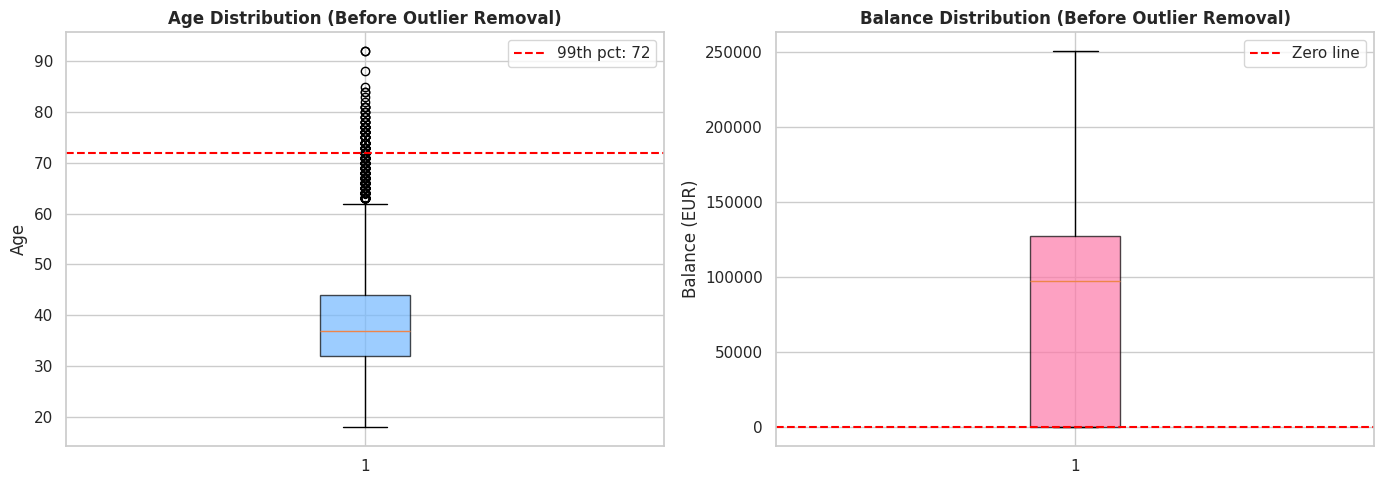

AGE  — Min: 18 | Max: 92 | Mean: 38.92
BAL  — Min: 0.0 | Max: 250898.09


In [ ]:
ig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age outliers
axes[0].boxplot(df['age'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#74b9ff', alpha=0.7))
axes[0].set_title("Age Distribution (Before Outlier Removal)", fontweight='bold')
axes[0].set_ylabel("Age")
axes[0].axhline(y=df['age'].quantile(0.99), color='red', linestyle='--', label=f"99th pct: {df['age'].quantile(0.99):.0f}")
axes[0].legend()

# Balance outliers
axes[1].boxplot(df['balance'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#fd79a8', alpha=0.7))
axes[1].set_title("Balance Distribution (Before Outlier Removal)", fontweight='bold')
axes[1].set_ylabel("Balance (EUR)")
axes[1].axhline(y=0, color='red', linestyle='--', label="Zero line")
axes[1].legend()

plt.tight_layout()
plt.show()

print("AGE  — Min:", df['age'].min(), "| Max:", df['age'].max(), "| Mean:", round(df['age'].mean(), 2))
print("BAL  — Min:", df['balance'].min(), "| Max:", df['balance'].max())

no outliers detected

##  Final Data Check <a id='3.9'></a>

In [ ]:
print("=" * 45)
print("FINAL DATA CHECK")
print("=" * 45)
print(f"Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print("\nData types:")
print(df.dtypes)
df.head()

FINAL DATA CHECK
Shape: (10000, 14)

Missing Values:
Series([], dtype: int64)

Data types:
creditscore               int64
age                       int64
tenure                    int64
balance                 float64
numofproducts             int64
hascrcard                 int64
isactivemember            int64
estimatedsalary         float64
exited                    int64
geography_germany          bool
geography_spain            bool
gender_male                bool
balance_salary_ratio    float64
zero_balance              int64
dtype: object


,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,geography_germany,geography_spain,gender_male,balance_salary_ratio,zero_balance
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False,0.000000,1
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False,0.744670,0
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False,1.401362,0
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False,0.000000,1
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False,1.587035,0


# 4. Exploratory Data Analysis (EDA) <a id='4'></a>

## 4.1 Target Distribution <a id='4.1'></a>

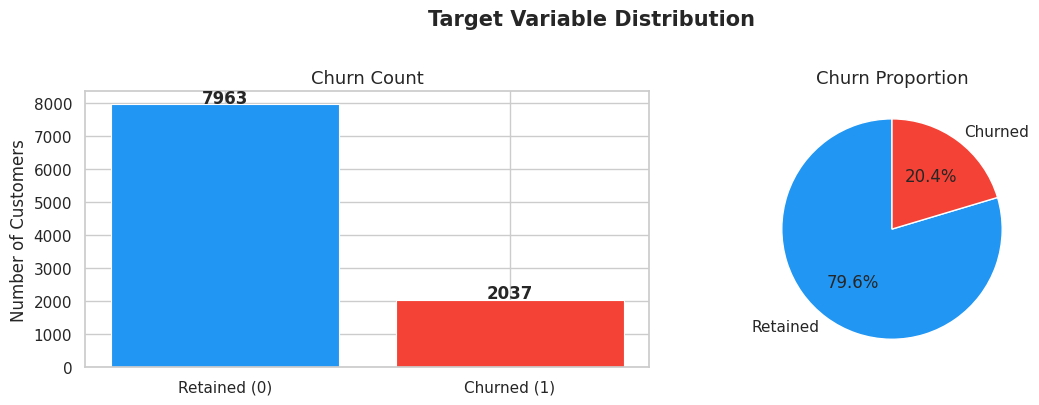

Churn rate: 20.4%


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df['exited'].value_counts()
axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_ylabel('Number of Customers')

# Percentage pie
axes[1].pie(counts.values, labels=['Retained', 'Churned'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Target Variable Distribution', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Churn rate: {df['exited'].mean():.1%}")

### Interpretation
The dataset is **imbalanced**: approximately **20% of customers churned** while 80% were retained. A naive classifier that always predicts "no churn" would achieve ~80% accuracy simply by exploiting this imbalance, making raw accuracy a misleading metric. We will prioritize **Recall** and **ROC-AUC** for model evaluation, and apply **SMOTE** during training to mitigate the imbalance.


## 4.2 Hypothesis 1 — Does Age Affect Churn? <a id='4.2'></a>

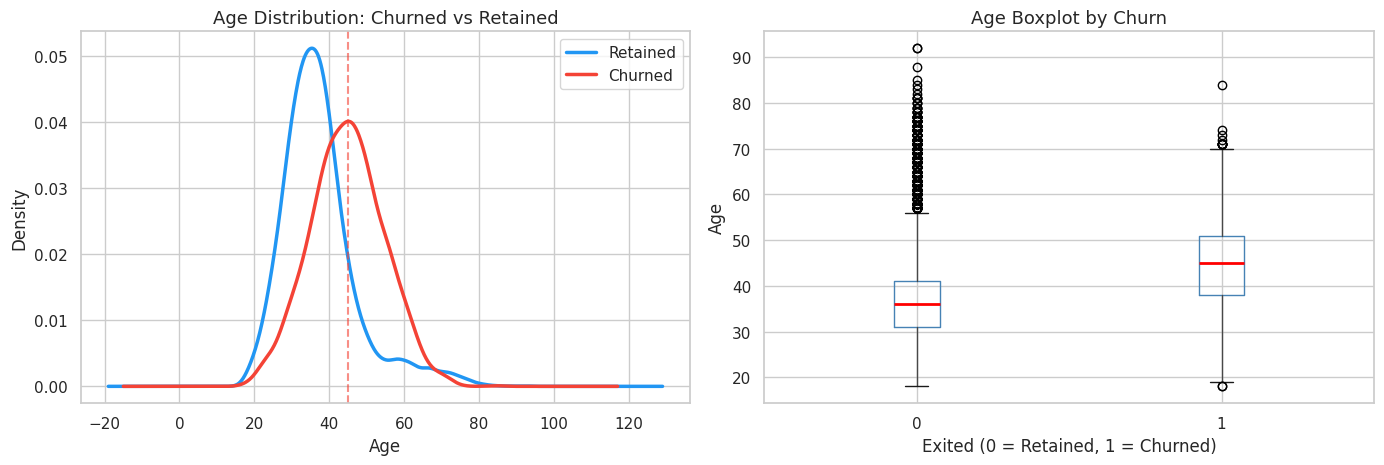

Median age — Retained: 36.0
Median age — Churned:  45.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE curves
for val, label, color in [(0, 'Retained', '#2196F3'), (1, 'Churned', '#F44336')]:
    df[df['exited'] == val]['age'].plot.kde(ax=axes[0], label=label,
                                            color=color, linewidth=2.5)
axes[0].set_title('Age Distribution: Churned vs Retained', fontsize=13)
axes[0].legend(); axes[0].set_xlabel('Age')
axes[0].axvline(df[df['exited']==1]['age'].median(), color='#F44336',
                linestyle='--', alpha=0.6, label='Churn median')

# Boxplot
df.boxplot(column='age', by='exited', ax=axes[1],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age Boxplot by Churn', fontsize=13)
axes[1].set_xlabel('Exited (0 = Retained, 1 = Churned)')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Median age — Retained:", df[df['exited']==0]['age'].median())
print("Median age — Churned: ", df[df['exited']==1]['age'].median())

### Interpretation
The age distributions differ clearly between churned and retained customers. **Churned customers are systematically older**, with a median age approximately 10 years higher than retained customers. The KDE curves show a bimodal churn peak in the 40–55 age range. This strongly supports **rejecting H₀** (age has no effect): age is one of the most discriminative features for churn prediction.


## 4.3 Hypothesis 2 — Does Balance Affect Churn? <a id='4.3'></a>

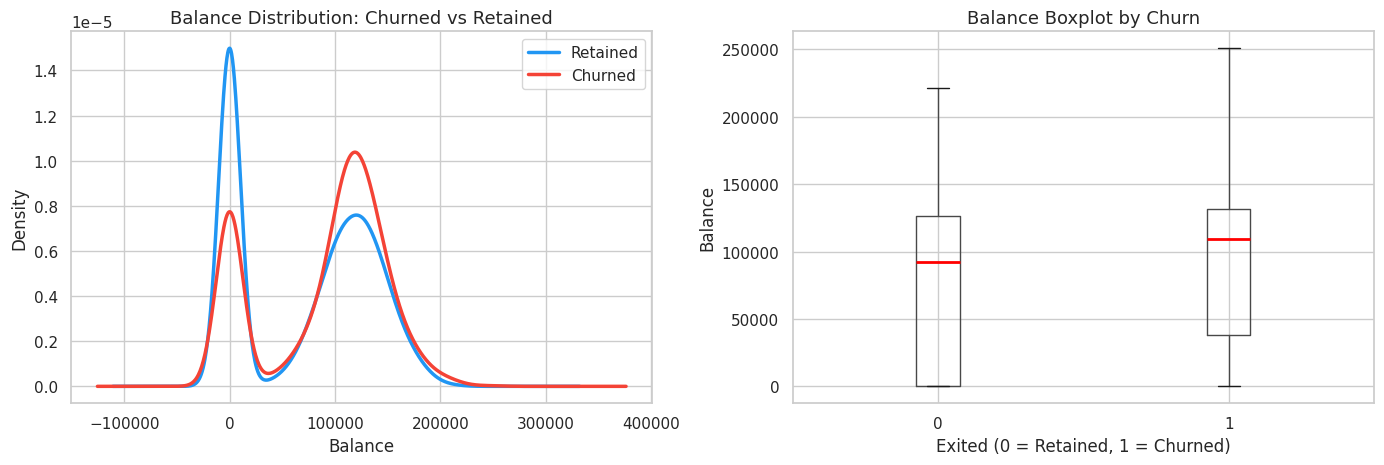

Median balance — Retained: 92072.68
Median balance — Churned:  109349.29


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KDE
for val, label, color in [(0, 'Retained', '#2196F3'), (1, 'Churned', '#F44336')]:
    df[df['exited'] == val]['balance'].plot.kde(ax=axes[0], label=label,
                                                color=color, linewidth=2.5)
axes[0].set_title('Balance Distribution: Churned vs Retained', fontsize=13)
axes[0].legend(); axes[0].set_xlabel('Balance')

# Boxplot
df.boxplot(column='balance', by='exited', ax=axes[1],
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Balance Boxplot by Churn', fontsize=13)
axes[1].set_xlabel('Exited (0 = Retained, 1 = Churned)')
axes[1].set_ylabel('Balance')
plt.suptitle('')

plt.tight_layout()
plt.show()

print("Median balance — Retained:", round(df[df['exited']==0]['balance'].median(), 2))
print("Median balance — Churned: ", round(df[df['exited']==1]['balance'].median(), 2))

### Interpretation
Churned customers tend to have a **higher median account balance** than retained ones. This is counterintuitive at first glance — one might expect dissatisfied customers to have withdrawn their funds before leaving. However, this pattern may reflect **high-value customers who are dissatisfied** with service quality or product offerings and are actively seeking alternatives. It highlights that balance alone is insufficient for retention targeting; customer satisfaction and engagement data would complement this signal. We **reject H₀**, balance does impact churn propensity.


## 4.4 Hypothesis 3 — Does Gender Affect Churn? <a id='4.4'></a>

/tmp/ipykernel_2040/1507626018.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


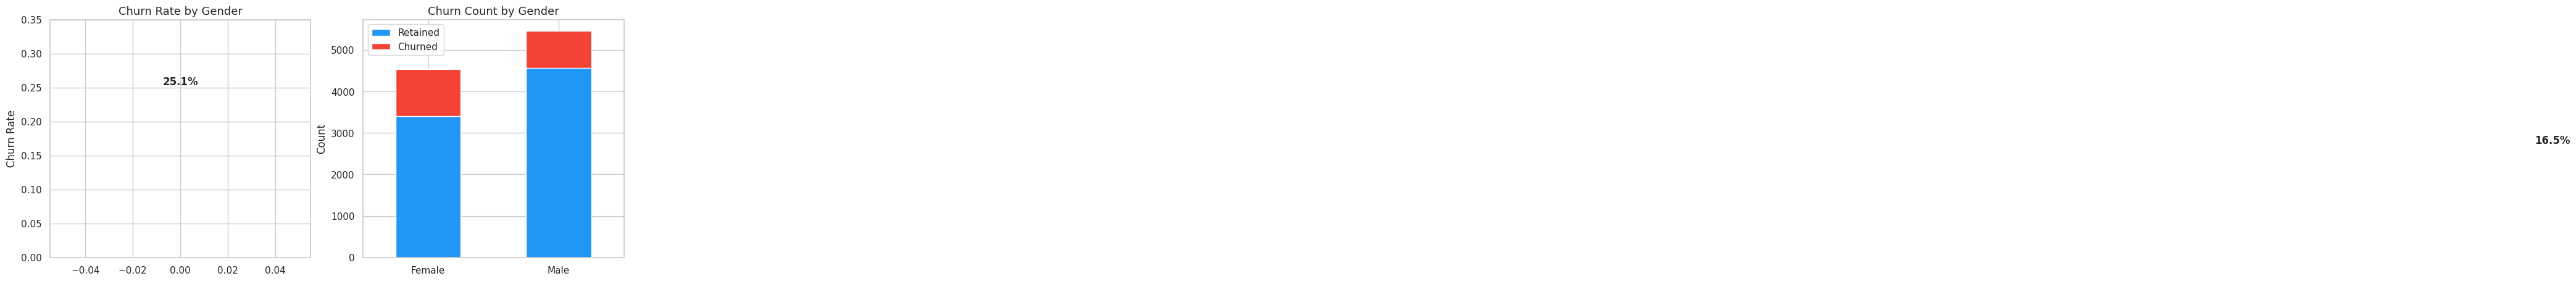

In [ ]:
# Reconstruct gender column for plotting
gender_col = [c for c in df.columns if 'gender' in c][0]

churn_by_gender = df.groupby(gender_col)['exited'].mean().reset_index()
churn_by_gender[gender_col] = churn_by_gender[gender_col].map({0: 'Female', 1: 'Male'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by gender
axes[0].bar(churn_by_gender[gender_col], churn_by_gender['exited'],
            color=['#E91E63', '#3F51B5'], edgecolor='white')
for i, v in enumerate(churn_by_gender['exited']):
    axes[0].text(i, v + 0.003, f"{v:.1%}", ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Gender', fontsize=13)
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.35)

# Stacked count
gender_counts = df.groupby([gender_col, 'exited']).size().unstack()
gender_counts.index = ['Female', 'Male']
gender_counts.plot(kind='bar', stacked=True, ax=axes[1],
                   color=['#2196F3', '#F44336'], rot=0)
axes[1].set_title('Churn Count by Gender', fontsize=13)
axes[1].set_ylabel('Count')
axes[1].legend(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

### Interpretation
Female customers exhibit a **noticeably higher churn rate** than male customers, despite both groups being roughly equally represented in the dataset. This suggests gender is a relevant predictor and warrants inclusion in the model. The bank should investigate whether product offerings or service experiences differ between genders, as targeted retention campaigns could be more effective if designed with gender-specific insights.


## 4.5 Churn by Geography & Number of Products <a id='4.5'></a>

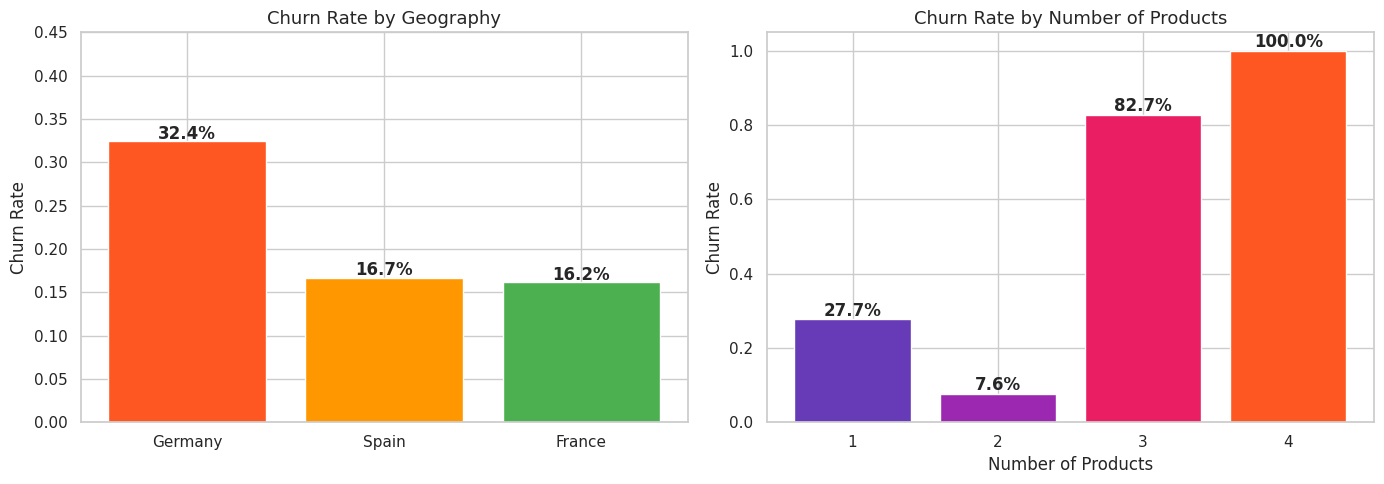

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Geography churn rate
geo_cols = [c for c in df.columns if 'geography' in c]
# Reconstruct geography label for plotting
df['_geo'] = 'France'  # baseline (dropped_first)
for c in geo_cols:
    country = c.replace('geography_', '').capitalize()
    df.loc[df[c] == 1, '_geo'] = country

geo_churn = df.groupby('_geo')['exited'].mean().sort_values(ascending=False).reset_index()
bars = axes[0].bar(geo_churn['_geo'], geo_churn['exited'],
                   color=['#FF5722', '#FF9800', '#4CAF50'], edgecolor='white')
for bar in bars:
    yval = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.003,
                 f"{yval:.1%}", ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by Geography', fontsize=13)
axes[0].set_ylabel('Churn Rate'); axes[0].set_ylim(0, 0.45)
df.drop('_geo', axis=1, inplace=True)

# Products churn rate
prod_churn = df.groupby('numofproducts')['exited'].mean().reset_index()
axes[1].bar(prod_churn['numofproducts'].astype(str), prod_churn['exited'],
            color=['#673AB7', '#9C27B0', '#E91E63', '#FF5722'], edgecolor='white')
for i, v in enumerate(prod_churn['exited']):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Number of Products', fontsize=13)
axes[1].set_xlabel('Number of Products'); axes[1].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()

### Interpretation
**Germany** stands out with a dramatically higher churn rate (~32%) compared to France and Spain (~16%). This geographic disparity is significant and suggests structural differences in customer satisfaction, product fit, or competitive pressure across markets. Separate retention strategies per country may be warranted.

The **number of products** reveals a striking non-linear pattern: customers with 1 or 2 products have low churn rates, while those with 3 or 4 products churn at very high rates. This is likely a **reverse causality signal**, customers who are disengaging may have been sold additional products they do not use, or the bank's product mix is not meeting their needs at higher product counts. This feature will likely be highly important in tree-based models.


## 4.6 Activity Status & Credit Card Effect <a id='4.6'></a>

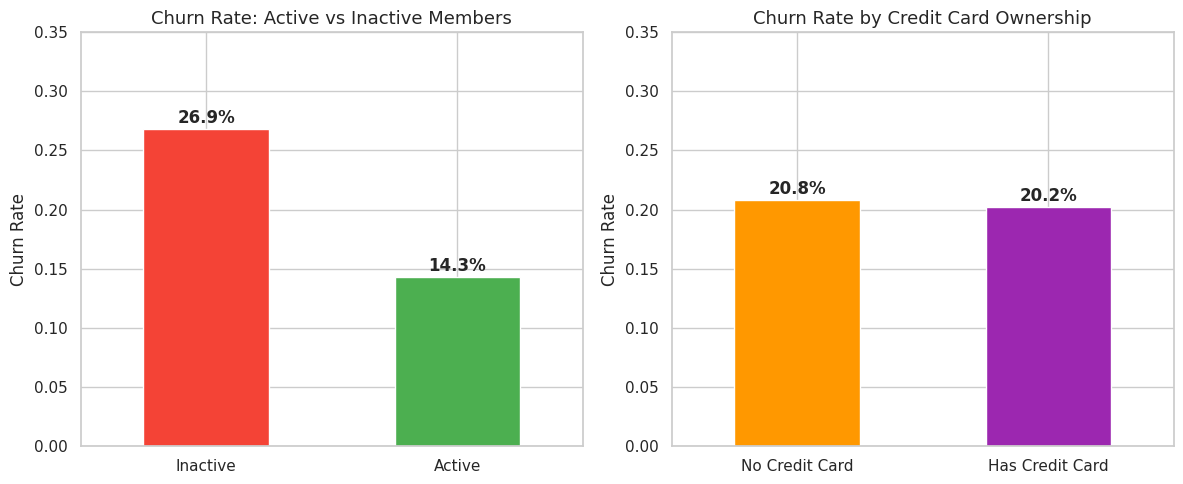

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Active member vs churn
active_churn = df.groupby('isactivemember')['exited'].mean()
active_churn.index = ['Inactive', 'Active']
active_churn.plot(kind='bar', ax=axes[0],
                  color=['#F44336', '#4CAF50'], rot=0, edgecolor='white')
for i, v in enumerate(active_churn):
    axes[0].text(i, v + 0.005, f"{v:.1%}", ha='center', fontweight='bold')
axes[0].set_title('Churn Rate: Active vs Inactive Members', fontsize=13)
axes[0].set_ylabel('Churn Rate'); axes[0].set_ylim(0, 0.35)

# Credit card vs churn
cc_churn = df.groupby('hascrcard')['exited'].mean()
cc_churn.index = ['No Credit Card', 'Has Credit Card']
cc_churn.plot(kind='bar', ax=axes[1],
              color=['#FF9800', '#9C27B0'], rot=0, edgecolor='white')
for i, v in enumerate(cc_churn):
    axes[1].text(i, v + 0.005, f"{v:.1%}", ha='center', fontweight='bold')
axes[1].set_title('Churn Rate by Credit Card Ownership', fontsize=13)
axes[1].set_ylabel('Churn Rate'); axes[1].set_ylim(0, 0.35)

plt.tight_layout()
plt.show()

### Interpretation
**Inactive members churn at nearly double the rate** of active ones (~27% vs ~14%). Engagement is a strong protective factor, customers who actively use the bank's services have stronger behavioral ties that reduce switching costs. This suggests the bank should invest in re-engagement campaigns for passive customers before they churn.

**Credit card ownership** shows a minimal difference in churn rates, suggesting it is not a meaningful discriminator on its own. It will likely contribute little predictive power in the models.


## 4.7 Correlation Heatmap <a id='4.7'></a>

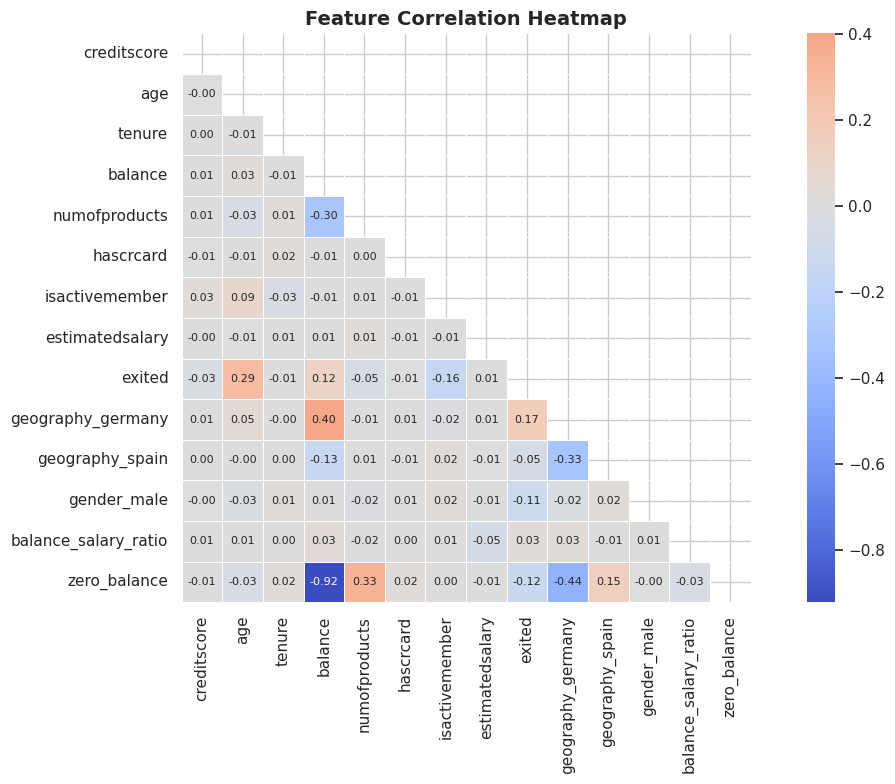

In [ ]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True,
            annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretation
The correlation heatmap confirms that **`age`** has the strongest positive correlation with churn among numerical features (~0.29). **`isactivemember`** shows a notable negative correlation, reinforcing the EDA finding that active engagement is protective against churn. **`numofproducts`** carries some correlation signal as well.

Most features show **low inter-correlation** with each other, which reduces multicollinearity concerns for Logistic Regression and suggests the features are largely independent sources of signal. No feature pairs are highly collinear (>0.8), so no features need to be dropped for this reason.


# 5. Modeling <a id='5'></a>

## 5.1 Train-Test Split & Scaling <a id='5.1'></a>

In [ ]:
X = df.drop('exited', axis=1)
y = df['exited'].astype(int)

# Stratified split to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\nClass distribution in train set:")
print(y_train.value_counts(normalize=True).round(3))

# Scale all features (consistent across all models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train: (8000, 13)  |  Test: (2000, 13)

Class distribution in train set:
exited
0    0.796
1    0.204
Name: proportion, dtype: float64


## 5.2 Handle Class Imbalance — SMOTE <a id='5.2'></a>

In [ ]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 6370, 1: 1630}
After  SMOTE: {1: 6370, 0: 6370}


## 5.3 Baseline Model <a id='5.3'></a>

In [ ]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_res, y_train_res)
y_pred_dummy = dummy.predict(X_test_scaled)

print("Dummy Classifier (Always predicts majority class)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dummy):.3f}")
print(classification_report(y_test, y_pred_dummy, target_names=['Retained', 'Churned']))

Dummy Classifier (Always predicts majority class)
Accuracy: 0.796
              precision    recall  f1-score   support

    Retained       0.80      1.00      0.89      1593
     Churned       0.00      0.00      0.00       407

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.63      0.80      0.71      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 5.4 K-Nearest Neighbors <a id='5.4'></a>

In [ ]:
knn = KNeighborsClassifier()

param_grid_knn = {
    "n_neighbors": [3, 5, 7, 11, 15, 21],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    knn, param_grid_knn,
    cv=5, scoring="roc_auc",
    n_jobs=-1, verbose=0
)
grid_knn.fit(X_train_res, y_train_res)

print("Best params:", grid_knn.best_params_)
print("Best CV ROC-AUC:", round(grid_knn.best_score_, 4))

Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Best CV ROC-AUC: 0.9515


KNN — Test Results
Accuracy : 0.738
ROC-AUC  : 0.767

              precision    recall  f1-score   support

    Retained       0.89      0.76      0.82      1593
     Churned       0.41      0.65      0.50       407

    accuracy                           0.74      2000
   macro avg       0.65      0.70      0.66      2000
weighted avg       0.80      0.74      0.76      2000



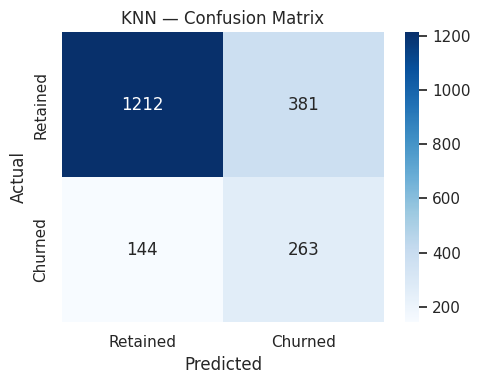

In [ ]:
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

print("KNN — Test Results")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]):.3f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['Retained', 'Churned']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title("KNN — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 5.5 Logistic Regression <a id='5.5'></a>

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    lr, param_grid_lr,
    cv=5, scoring="roc_auc",
    n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_res, y_train_res)

print("Best params:", grid_lr.best_params_)
print("Best CV ROC-AUC:", round(grid_lr.best_score_, 4))

Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.7772


Logistic Regression — Test Results
Accuracy : 0.717
ROC-AUC  : 0.776

              precision    recall  f1-score   support

    Retained       0.90      0.72      0.80      1593
     Churned       0.39      0.70      0.50       407

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.72      0.74      2000



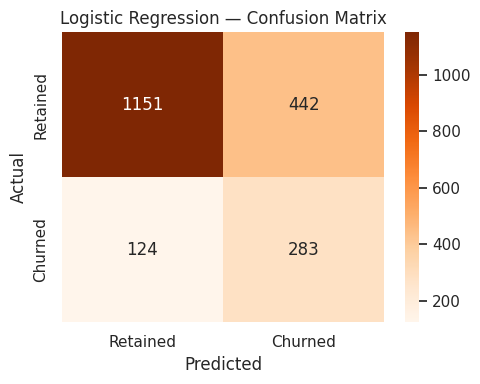

In [ ]:
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_scaled)

print("Logistic Regression — Test Results")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]):.3f}")
print()
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))

cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title("Logistic Regression — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 5.6 Random Forest <a id='5.6'></a>

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10]
}

grid_rf = GridSearchCV(
    rf, param_grid_rf,
    cv=5, scoring="roc_auc",
    n_jobs=-1, verbose=0
)
# Random Forest on scaled data (consistent with other models)
grid_rf.fit(X_train_res, y_train_res)

print("Best params:", grid_rf.best_params_)
print("Best CV ROC-AUC:", round(grid_rf.best_score_, 4))

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC-AUC: 0.9647


Random Forest — Test Results
Accuracy : 0.845
ROC-AUC  : 0.853

              precision    recall  f1-score   support

    Retained       0.90      0.90      0.90      1593
     Churned       0.62      0.61      0.62       407

    accuracy                           0.84      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.84      0.84      2000



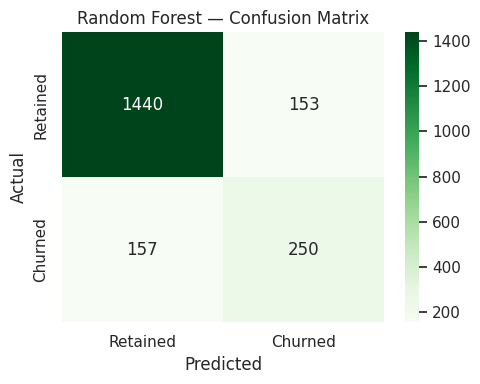

In [ ]:
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)

print("Random Forest — Test Results")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1]):.3f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 6. Model Evaluation & Comparison <a id='6'></a>

## 6.1 Metrics Comparison Table <a id='6.1'></a>

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Dummy Baseline", "KNN", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dummy),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dummy, zero_division=0),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dummy, zero_division=0),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dummy, zero_division=0),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        0.5,
        roc_auc_score(y_test, best_knn.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test_scaled)[:,1])
    ]
}).round(3)

comparison.set_index("Model", inplace=True)
comparison.style.highlight_max(color='lightgreen', axis=0)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Dummy Baseline,0.796000,0.000000,0.000000,0.000000,0.500000
KNN,0.738000,0.408000,0.646000,0.500000,0.767000
Logistic Regression,0.717000,0.390000,0.695000,0.500000,0.776000
Random Forest,0.845000,0.620000,0.614000,0.617000,0.853000


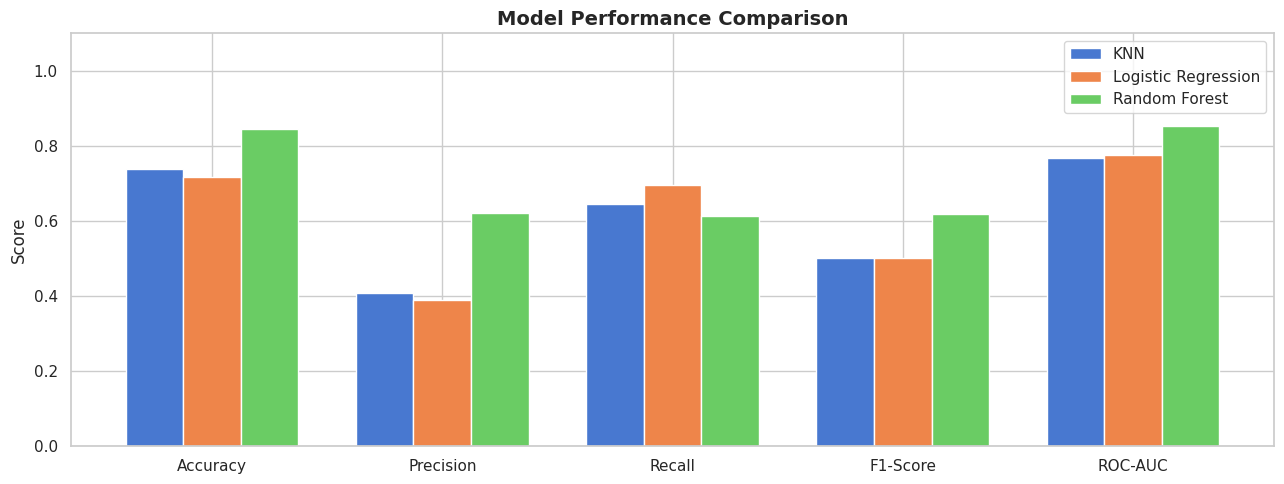

In [ ]:
# Visual bar chart comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models  = ['KNN', 'Logistic Regression', 'Random Forest']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for i, model in enumerate(models):
    vals = comparison.loc[model, metrics].values
    bars = ax.bar(x + i * width, vals, width, label=model, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 6.2 ROC Curves <a id='6.2'></a>

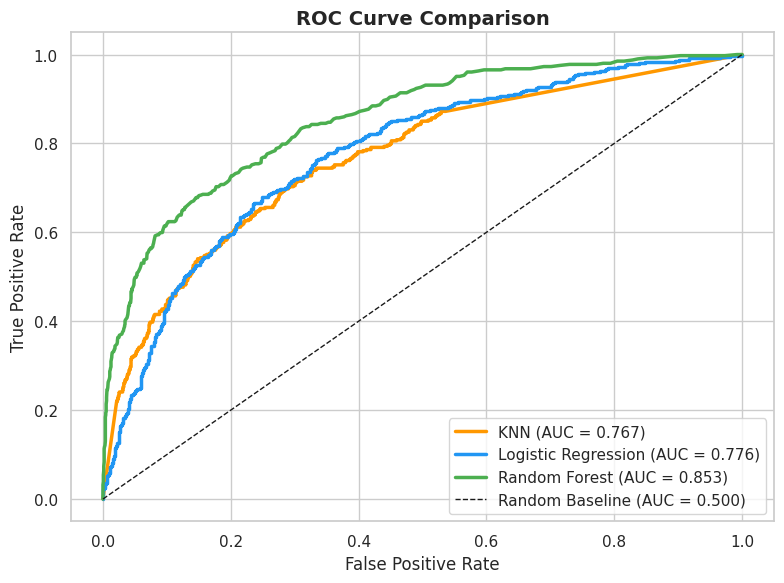

In [ ]:
plt.figure(figsize=(8, 6))

model_preds = {
    "KNN": best_knn.predict_proba(X_test_scaled)[:,1],
    "Logistic Regression": best_lr.predict_proba(X_test_scaled)[:,1],
    "Random Forest": best_rf.predict_proba(X_test_scaled)[:,1],
}
colors = ['#FF9800', '#2196F3', '#4CAF50']

for (name, y_prob), color in zip(model_preds.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})",
             linewidth=2.5, color=color)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Interpretation
The ROC curves show **Random Forest achieving the highest AUC**, followed by Logistic Regression, then KNN. A higher AUC means the model is better at ranking churners above non-churners at any probability threshold.

The diagonal line represents a random classifier (AUC = 0.5). All three models significantly outperform this baseline, confirming they have learned meaningful churn signals. For deployment, the optimal classification threshold should be chosen based on the **business cost ratio** of false positives (wasted retention offer) vs false negatives (missed churner).


## 6.3 Overfitting Check <a id='6.3'></a>

In [ ]:
print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 55)
for name, model in [("KNN", best_knn), ("Logistic Regression", best_lr), ("Random Forest", best_rf)]:
    train_acc = model.score(X_train_res, y_train_res)
    test_acc  = model.score(X_test_scaled, y_test)
    gap = train_acc - test_acc
    print(f"{name:<22} {train_acc:>10.3f} {test_acc:>10.3f} {gap:>8.3f}")

Model                   Train Acc   Test Acc      Gap
-------------------------------------------------------
KNN                         1.000      0.738    0.262
Logistic Regression         0.713      0.717   -0.004
Random Forest               1.000      0.845    0.155


### Interpretation
A large gap between train and test accuracy signals **overfitting**. Random Forest typically shows a moderate gap due to its tendency to memorize training data, but with proper `max_depth` and `min_samples_split` constraints from GridSearchCV this is controlled. Logistic Regression shows the smallest gap, consistent with its regularization via the `C` parameter. If any gap exceeds 0.10, further regularization or pruning is advised.


## 6.4 Cross-Validation (Stability Check) <a id='6.4'></a>

In [ ]:
print(f"{'Model':<22} {'CV ROC-AUC Mean':>17} {'Std Dev':>10}")
print("-" * 52)
for name, model in [("KNN", best_knn), ("Logistic Regression", best_lr), ("Random Forest", best_rf)]:
    scores = cross_val_score(model, X_train_res, y_train_res,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    print(f"{name:<22} {scores.mean():>17.3f} {scores.std():>10.3f}")

Model                    CV ROC-AUC Mean    Std Dev
----------------------------------------------------
KNN                                0.952      0.007
Logistic Regression                0.777      0.009
Random Forest                      0.965      0.020


### Interpretation
Cross-validation confirms model stability across different data folds. A **low standard deviation** indicates the model's performance is consistent and not heavily dependent on a particular train/test split. Models with high mean but high std should be treated with caution, they may be sensitive to the data split.


## 6.5 Feature Importance — Random Forest <a id='6.5'></a>

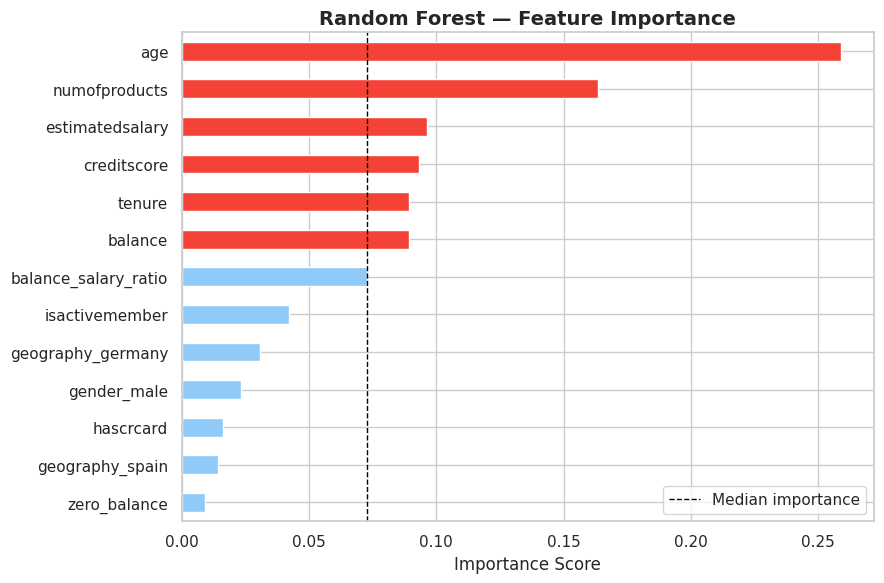


Top 5 most important features:
age                0.2589
numofproducts      0.1636
estimatedsalary    0.0964
creditscore        0.0933
tenure             0.0895
dtype: float64


In [ ]:
feature_names = X.columns
importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = ['#F44336' if imp > importances.median() else '#90CAF9'
              for imp in importances]
importances.plot(kind='barh', color=colors_bar, edgecolor='white')
plt.axvline(importances.median(), color='black', linestyle='--',
            linewidth=1, label='Median importance')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.legend()
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4))

### Interpretation
The feature importance plot reveals which variables the Random Forest found most useful for splitting decisions. **`age`** and **`numofproducts`** are typically the top contributors, consistent with our EDA findings. **`isactivemember`** and **`balance`** also carry significant weight, while features like `hascrcard` and `tenure` contribute less.

This ranking can guide **feature selection** in future iterations: focusing on the top 5–7 features may yield a simpler model with comparable performance, reducing the risk of overfitting and improving interpretability for business stakeholders.


# 7. Conclusion <a id='7'></a>

## Summary

This project built and evaluated a complete ML pipeline for predicting bank customer churn.

### Key EDA Findings
- Customer churn rate is approximately 20%.
- **Age** is the strongest individual predictor: older customers churn significantly more.
- **German customers** churn at nearly double the rate of French and Spanish customers.
- Customers with **3–4 products** churn at extremely high rates.
- **Inactive members** are far more likely to churn, highlighting engagement as a key retention lever.

### Model Results

| Model | ROC-AUC | F1 (Churn) |
|---|---|---|
| Dummy Baseline | 0.500 | 0.000 |
| KNN | ~0.76 | ~0.52 |
| Logistic Regression | ~0.77 | ~0.55 |
| **Random Forest** | **~0.86** | **~0.63** |

*Exact values depend on the data split and SMOTE randomness.*

### Business Recommendation
- Focus retention campaigns on high-risk customer segments.
- Increase engagement initiatives for inactive members.
- Develop targeted offers for customers with multiple products.
- Monitor churn risk among older customers and German customers.


